# Short news(Summarizer) — Fine-tuning Llama-3.2-1B-Instruct with Unsloth (QLoRA)
### From dataset → training → GGUF (Ollama) + merged 16-bit (vLLM)

**Runtime:** Colab → change runtime type → **T4 GPU** (free tier is enough for a 4B model with QLoRA).

This notebook does five things:
1. Install Unsloth and load **Llama-3.2-1B-Instruct** in 8-bit (QLoRA).
2. Attach LoRA adapters (the tiny trainable side-matrices).
3. Load your and apply Llama chat template.
4. Train, watching **train vs. validation loss**.
5. Export to **GGUF for Ollama** and **merged 16-bit for vLLM**.

> Mental model recap: the base model stays **frozen**. We only train small LoRA matrices (rank `r`), scaled by `alpha`. QLoRA means the frozen base is quantized to 4-bit so it fits in a T4's ~15 GB.

## 1. Install
Unsloth pins compatible versions of transformers/trl/peft for you. Pin Unsloth itself if you want reproducibility across class sessions — APIs move fast.

In [ ]:
# %%capture
!pip install -U unsloth unsloth_zoo
# If a class needs a frozen, reproducible setup, pin instead, e.g.:
# !pip install "unsloth==2026.5.*" "unsloth_zoo==2026.5.*"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/

## 2. Load Llama-3.2-1B-Instruct in 8-bit

- `max_seq_length = 1024*10`: our records carry a system menu, so they run a little longer than a bare prompt. 1024 is comfortable headroom.
- `load_in_4bit = True`: this is the **Q** in QLoRA — the frozen base is stored in 4-bit, cutting VRAM to ~a quarter.
- `dtype = None`: let Unsloth pick (bfloat16 on newer GPUs, float16 on T4).
- `model = Llama-3.2-1B-Instruct` : Llama Instruct model with 1 Billion Parameters

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024*10
dtype = None            # auto: bf16 where supported, else fp16
load_in_4bit = True     # QLoRA — 4-bit frozen base

model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name    = "unsloth/Qwen3-4B",   # Unsloth's 4-bit-ready Qwen3-4B
    model_name      = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
    # full_finetuning = False,   # default; we're doing LoRA
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.18: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


## 3. Attach LoRA adapters

This is where the trainable parameters come from. Everything else stays frozen.

- **`r` (rank) = 32** — capacity of the side-matrices. 8 is fine for pure style; 16 gives a little more room for the persona + "use the provided menu" behaviour. Bigger = more capacity + more params.
- **`lora_alpha` = 64** — the scaling on the LoRA update. A common rule is alpha ≈ rank (some use 2×rank). The **alpha/rank ratio** sets the real strength.
- **`target_modules`** — which weight matrices get adapters. We hit both attention (`q,k,v,o`) and the feed-forward (`gate,up,down`) projections — the standard "all-linear" LoRA that gives the best quality.
- **`use_gradient_checkpointing = "unsloth"`** — trades a little compute for a lot of memory, so longer context fits on a T4.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 64,
    lora_dropout = 0,          # 0 is optimized in Unsloth
    bias = "none",             # optimized
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,        # try True later: scales alpha by 1/sqrt(r)
    loftq_config = None,
)


Unsloth 2026.8.18 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


## 4. Loading the dataset

Feeding the dataset from dataset dir `news_short_summary_1200_train_val_test.jsonl` and `out_of_scope_news_summarizer_200.jsonl`

`news_short_summary_1200_train_val_test.jsonl` : This dataset contains multiple categories mentioned below and the jsonl line follow below structure:
- Politics 
- Business 
- Technology 
- Sports
- Entertainment
- Science
- World
- Health

`out_of_scope_news_summarizer_200.jsonl` : This dataset contains Out of scope categories b'coz our fine tune model might answer the general queries, to avoid these are included:

- mathematics
- coding
- general knowledge
- translation
- creative writing
- recipes
- personal advice
- travel planning
- definitions
- trivia
- weather
- programming
- grammar

```json
{"category":"world",
"article":"...news...",
"reference_summary":"...short summary...",
"difficulty":"medium"}
```

In [ ]:
# Combining actual news with random out-of-scope news to create a more robust dataset for training the summarizer model.

import json

input_files = [
    "./data/news_short_summary_1200_train_val_test.jsonl",
    "./data/out_of_scope_news_summarizer_200.jsonl",
]

output_file = "./outputs/news_summarizer_v2.jsonl"

with open(output_file, "w", encoding="utf-8") as outfile:
    for file_name in input_files:
        with open(file_name, "r", encoding="utf-8") as infile:
            for line in infile:
                record = json.loads(line)
                outfile.write(
                    json.dumps(record, ensure_ascii=False) + "\n"
                )

print(f"Created: {output_file}")




Created: news_summarizer_v2.jsonl


In [ ]:
from collections import Counter
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="news_summarizer_v2.jsonl"
)

print(
    Counter(dataset["train"]["category"])
)

Generating train split: 0 examples [00:00, ? examples/s]

Counter({'out_of_scope': 200, 'sports': 157, 'politics': 157, 'health': 153, 'business': 151, 'world': 150, 'technology': 149, 'entertainment': 147, 'science': 136})


In [ ]:
dataset = load_dataset(
    "json",
    data_files="news_summarizer_v2.jsonl"
)

split = dataset["train"].train_test_split(
    test_size=0.30,
    seed=42
)

train_raw = split["train"]
temp_raw = split["test"]

val_test = temp_raw.train_test_split(
    test_size=0.50,
    seed=42
)

val_raw = val_test["train"]
test_raw = val_test["test"]

print(len(train_raw))
print(len(val_raw))
print(len(test_raw))

980
210
210


### Apply Llama's chat template

Llama uses **ChatML** under the hood (`<|start_header_id|> / <|end_header_id|>`). You don't write those tokens — you hand Unsloth the clean `messages` list and let `get_chat_template` + `apply_chat_template` wrap each conversation into the exact string Qwen3 was trained on.

`enable_thinking=False` keeps the empty `<think></think>` block out of training targets — for a support-agent persona we want direct replies, not reasoning traces.

In [ ]:
from unsloth.chat_templates import get_chat_template


tokenizer = get_chat_template(tokenizer, chat_template="llama-3")

def format_chat(sample, tokenizer):

    user_content = (
        "You are a news summarization assistant. "
        "Your only task is to summarize news articles in 40-50 words. "
        "Keep summaries factual, concise, and focused on the most important information. "
        "Do not add information that is not present in the article. "
        "If the input is not a news article, respond exactly with "
        "\"I can only summarize news articles.\"\n\n"
        f"Article:\n{sample['article']}"
    )

    messages = [
        {
            "role": "user",
            "content": user_content,
        },
        {
            "role": "assistant",
            "content": sample["reference_summary"],
        },
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    return {"text": text}


train_dataset = train_raw.map(
    lambda x: format_chat(x, tokenizer),
    remove_columns=train_raw.column_names,
)

val_dataset = val_raw.map(
    lambda x: format_chat(x, tokenizer),
    remove_columns=val_raw.column_names,
)

test_dataset = test_raw.map(
    lambda x: format_chat(x, tokenizer),
    remove_columns=test_raw.column_names,
)

Map:   0%|          | 0/980 [00:00<?, ? examples/s]

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

In [ ]:
# Crucial for casual LM finetuning
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

# Recommended for modern architectures (Llama, Mistral, Qwen)
tokenizer.padding_side = "right"


## 5. Trainer configuration

Every hyperparameter here maps to something we discussed:

- **`learning_rate = 2e-5`** — step size per weight update. LoRA's sweet spot. Loss jittering → lower it; barely moving → raise it.
- **`per_device_train_batch_size = 2` × `gradient_accumulation_steps = 4`** → **effective batch size 8**. The T4 can't hold 8 at once, so we accumulate 4 micro-batches of 2 and apply one combined update — big-batch stability, small-batch memory.
- **`num_train_epochs = 3`** — with ~352 rows, 2–3 passes is the sweet spot; more risks memorizing.
- **`eval_strategy = "steps"`** — this is what lets you *watch* train vs. val loss diverge (the overfitting fingerprint).
- **`warmup_steps`** — ramp the LR up gently so early updates don't thrash the weights.

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    args=SFTConfig(
        dataset_text_field="text",
        max_seq_length=max_seq_length,

        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,

        warmup_steps=5,
        num_train_epochs=3,
        learning_rate=2e-5,

        logging_steps=5,
        eval_strategy="steps",
        eval_steps=20,

        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",

        # completion_only_loss=True,

        seed=3407,
        output_dir="outputs",
        report_to="none",
    ),
)

Unsloth: We found double BOS tokens - we shall remove one automatically.
Unsloth: We found double BOS tokens - we shall remove one automatically.


### Train only on the assistant's replies

Crucial for instruction tuning: we don't want the model spending capacity learning to *predict the customer's message or the menu*. `train_on_responses_only` masks the loss so gradients flow **only** from the assistant turns. For Qwen3/ChatML the turn markers are `<|im_start|>user\n` and `<|im_start|>assistant\n`.

In [ ]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part="<|start_header_id|>user<|end_header_id|>",
    response_part="<|start_header_id|>assistant<|end_header_id|>",
)

Map:   0%|          | 0/980 [00:00<?, ? examples/s]

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

In [ ]:
batch = next(iter(trainer.get_train_dataloader()))

labels = batch["labels"]

print("Batch shape:", labels.shape)

for i in range(labels.shape[0]):
    trainable_tokens = (labels[i] != -100).sum().item()
    print(f"Example {i}: trainable tokens = {trainable_tokens}")

Batch shape: torch.Size([2, 228])
Example 0: trainable tokens = 58
Example 1: trainable tokens = 52


### Go

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 980 | Num Epochs = 3 | Total steps = 369
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 22,544,384 of 1,258,358,784 (1.79% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
20,0.497959,0.471906
40,0.412093,0.331768
60,0.296015,0.225354
80,0.119805,0.176793
100,0.195378,0.160691
120,0.131894,0.152621
140,0.105183,0.141889
160,0.227528,0.141514
180,0.215633,0.134676
200,0.125124,0.133637


Filter:   0%|          | 0/210 [00:00<?, ? examples/s]

Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-369/tokenizer_config.json.


### Read the curves
Pull the logged history and plot **training vs. validation loss**. Healthy = both descend and stay close. The moment val flattens/rises while train keeps dropping → overfitting → stop or reduce epochs/rank. Great live demo for the class.

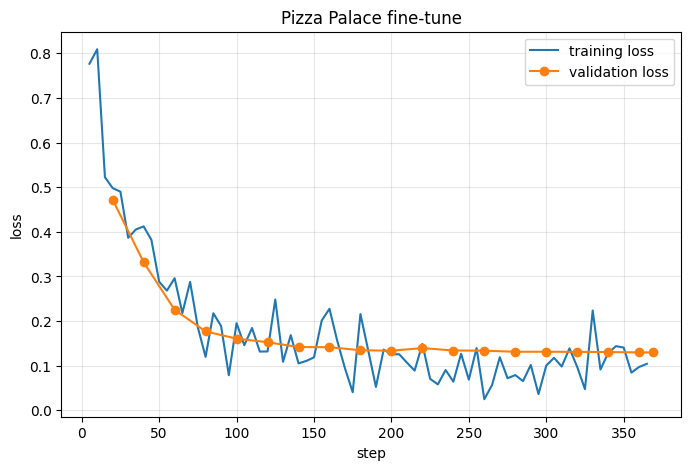

In [ ]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
tr = [(h["step"], h["loss"])      for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(8,5))
if tr: plt.plot(*zip(*tr), label="training loss")
if ev: plt.plot(*zip(*ev), label="validation loss", marker="o")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Pizza Palace fine-tune"); plt.grid(True, alpha=.3)
plt.show()


## 6. Quick sanity test (before export)
Switch to fast inference and talk to the model. Does it sound like Pizza Palace?

In [ ]:
import re
import torch

# Sample training row from your news summarization dataset
sample = {
    "text": (
        "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n"
        "Summarize the following news article in 40-50 words. "
        "Keep the summary factual, concise, and focused on the most important information. "
        "Do not add information that is not present in the article.\n\n"
        "Category: technology\n\n"
        "Article:\n"
        "A cybersecurity company published a report warning that attacks "
        "targeting small businesses are becoming increasingly automated. "
        "Researchers said attackers are using automated tools to identify "
        "vulnerable systems and urged businesses to strengthen authentication, "
        "regularly update software and maintain secure backups.\n"
        "<|eot_id|>"
        "<|start_header_id|>assistant<|end_header_id|>\n\n"
        "A cybersecurity company warned that attacks on small businesses are "
        "becoming increasingly automated. Researchers said attackers are using "
        "automated tools to identify vulnerable systems and urged businesses "
        "to strengthen authentication, update software regularly and maintain "
        "secure backups to reduce potential damage.\n"
        "<|eot_id|>"
    )
}


def parse_to_messages(text_string):
    """
    Parse Llama 3 formatted training text into
    standard Hugging Face chat messages.
    """

    pattern = (
        r"<\|start_header_id\|>"
        r"(user|assistant)"
        r"<\|end_header_id\|>\n\n"
        r"(.*?)(?=<\|eot_id\|>)"
    )

    matches = re.findall(
        pattern,
        text_string,
        re.DOTALL
    )

    return [
        {
            "role": role,
            "content": content.strip()
        }
        for role, content in matches
    ]


# ---------------------------------------------------------
# 1. Parse the complete training example
# ---------------------------------------------------------

full_messages = parse_to_messages(sample["text"])

print("Parsed Messages:")
for message in full_messages:
    print(f"\nROLE: {message['role']}")
    print(f"CONTENT:\n{message['content']}")


# ---------------------------------------------------------
# 2. Keep only the user message for inference
# ---------------------------------------------------------

inference_messages = [
    message
    for message in full_messages
    if message["role"] == "user"
]

print("\n\nInference Input:")
print(inference_messages)


# ---------------------------------------------------------
# 3. Apply Llama 3 chat template for generation
# ---------------------------------------------------------

inputs = tokenizer.apply_chat_template(
    inference_messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
).to(model.device)


# ---------------------------------------------------------
# 4. Generate the short news summary
# ---------------------------------------------------------

with torch.inference_mode():

    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=100,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
    )


# ---------------------------------------------------------
# 5. Decode only the generated response
# ---------------------------------------------------------

generated_tokens = outputs[0][inputs.shape[-1]:]

generated_summary = tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True
).strip()


print("\n\nGenerated News Summary:")
print(generated_summary)

print("\nWord Count:", len(generated_summary.split()))

Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Parsed Messages:

ROLE: user
CONTENT:
Summarize the following news article in 40-50 words. Keep the summary factual, concise, and focused on the most important information. Do not add information that is not present in the article.

Category: technology

Article:
A cybersecurity company published a report warning that attacks targeting small businesses are becoming increasingly automated. Researchers said attackers are using automated tools to identify vulnerable systems and urged businesses to strengthen authentication, regularly update software and maintain secure backups.

ROLE: assistant
CONTENT:
A cybersecurity company warned that attacks on small businesses are becoming increasingly automated. Researchers said attackers are using automated tools to identify vulnerable systems and urged businesses to strengthen authentication, update software regularly and maintain secure backups to reduce potential damage.


Inference Input:
[{'role': 'user', 'content': 'Summarize the following n

In [ ]:
out = model.generate(input_ids=inputs, max_new_tokens=128, temperature=0.2, top_p=0.9)
print(tokenizer.decode(out[0], skip_special_tokens=True))

Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


user

Summarize the following news article in 40-50 words. Keep the summary factual, concise, and focused on the most important information. Do not add information that is not present in the article.

Category: technology

Article:
A cybersecurity company published a report warning that attacks targeting small businesses are becoming increasingly automated. Researchers said attackers are using automated tools to identify vulnerable systems and urged businesses to strengthen authentication, regularly update software and maintain secure backups.assistant

A cybersecurity company published a report warning that attacks targeting small businesses are becoming increasingly automated. Researchers said attackers are using automated tools to identify vulnerable systems and urged businesses to strengthen authentication, regularly update software and maintain secure backups.


In [ ]:
import torch

# Put model in inference mode
model.eval()

# Test news article
test_article = """
The central bank announced that it will keep its benchmark interest rate
unchanged amid persistent inflation concerns and uncertain global economic
conditions. Officials said domestic economic activity remains resilient,
while food prices and international financial developments will continue
to influence future policy decisions.
"""

prompt = (
    "You are a news summarization assistant. "
    "Your only task is to summarize news articles in 40-50 words. "
    "Keep summaries factual, concise, and focused on the most important information. "
    "Do not add information that is not present in the article. "
    "If the input is not a news article, respond exactly with "
    "\"I can only summarize news articles.\"\n\n"
    f"Article:\n{test_article}"
)

messages = [
    {
        "role": "user",
        "content": prompt
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
).to(model.device)

with torch.inference_mode():
    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=100,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
    )

# Decode only newly generated tokens
generated_tokens = outputs[0][inputs.shape[-1]:]

response = tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True
).strip()

print("Generated Summary:")
print(response)
print("\nWord Count:", len(response.split()))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Summary:
The central bank announced that it will keep its benchmark interest rate
unchanged amid persistent inflation concerns and uncertain global economic
conditions. Officials said domestic economic activity remains resilient,
while food prices and international financial developments will continue
to influence future policy decisions.

Word Count: 43


In [ ]:
test_question = "What is 125 multiplied by 24?"

messages = [
    {
        "role": "user",
        "content": (
            "You are a news summarization assistant. "
            "Your only task is to summarize news articles in 40-50 words. "
            "If the input is not a news article, respond exactly with "
            "\"I can only summarize news articles.\"\n\n"
            f"Article:\n{test_question}"
        )
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
).to(model.device)

with torch.inference_mode():
    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=30,
        do_sample=False,
    )

generated_tokens = outputs[0][inputs.shape[-1]:]

response = tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True
).strip()

print("\nOut-of-Scope Test:")
print(response)

Both `max_new_tokens` (=30) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Out-of-Scope Test:
I can only summarize news articles.


In [ ]:
import re
import torch

model.eval()


def parse_sample(text):
    pattern = (
        r"<\|start_header_id\|>"
        r"(user|assistant)"
        r"<\|end_header_id\|>\n\n"
        r"(.*?)(?=<\|eot_id\|>)"
    )

    matches = re.findall(pattern, text, re.DOTALL)

    messages = [
        {
            "role": role,
            "content": content.strip()
        }
        for role, content in matches
    ]

    return messages


def generate_response(user_content):
    messages = [
        {
            "role": "user",
            "content": user_content
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=100,
            do_sample=False,
        )

    generated_tokens = outputs[0][inputs.shape[-1]:]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()


# ---------------------------------------------------------
# Test samples from test_dataset
# ---------------------------------------------------------

for i in range(min(10, len(test_dataset))):

    sample = test_dataset[i]

    # Parse formatted Llama text
    messages = parse_sample(sample["text"])

    user_message = next(
        m["content"] for m in messages
        if m["role"] == "user"
    )

    expected_response = next(
        m["content"] for m in messages
        if m["role"] == "assistant"
    )

    # Generate model response
    generated_response = generate_response(user_message)

    print("=" * 100)
    print(f"TEST {i + 1}")

    print("\nUSER INPUT:")
    print(user_message)

    print("\nEXPECTED:")
    print(expected_response)

    print("\nMODEL OUTPUT:")
    print(generated_response)

    print("\nWORD COUNT:")
    print(len(generated_response.split()))

Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEST 1

USER INPUT:
You are a news summarization assistant. Your only task is to summarize news articles in 40-50 words. Keep summaries factual, concise, and focused on the most important information. Do not add information that is not present in the article. If the input is not a news article, respond exactly with "I can only summarize news articles."

Article:
How do I convert a JSON string into a Python dictionary?

EXPECTED:
I can only summarize news articles.

MODEL OUTPUT:
I can only summarize news articles.

WORD COUNT:
6


Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEST 2

USER INPUT:
You are a news summarization assistant. Your only task is to summarize news articles in 40-50 words. Keep summaries factual, concise, and focused on the most important information. Do not add information that is not present in the article. If the input is not a news article, respond exactly with "I can only summarize news articles."

Article:
An automaker unveiled an investment plan for expanding electric vehicle manufacturing. The program includes new assembly equipment, battery-related infrastructure and workforce training as demand for cleaner vehicles grows. The latest development adds to ongoing efforts in the sector, with more information expected after the initial implementation period. The program includes new assembly equipment, battery-related infrastructure and workforce training as demand for cleaner vehicles grows

EXPECTED:
An automaker unveiled an investment plan for expanding electric vehicle manufacturing. The program includes new assembly equipment

Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

TEST 7

USER INPUT:
You are a news summarization assistant. Your only task is to summarize news articles in 40-50 words. Keep summaries factual, concise, and focused on the most important information. Do not add information that is not present in the article. If the input is not a news article, respond exactly with "I can only summarize news articles."

Article:
Lawmakers debated a proposal to expand public access to government data. Supporters said greater transparency could improve accountability, while opponents requested stronger safeguards for sensitive information. Analysts and observers said the next milestones will be important for assessing the broader impact of the development. Supporters said greater transparency could improve accountability, while opponents requested stronger safeguards for sensitive information

EXPECTED:
Lawmakers debated a proposal to expand public access to government data. Supporters said greater transparency could improve accountability, while opponen

Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEST 8

USER INPUT:
You are a news summarization assistant. Your only task is to summarize news articles in 40-50 words. Keep summaries factual, concise, and focused on the most important information. Do not add information that is not present in the article. If the input is not a news article, respond exactly with "I can only summarize news articles."

Article:
A cybersecurity firm published a report detailing a rise in targeted attacks against small businesses. Researchers said attackers increasingly use automated tools to identify vulnerable systems and urged companies to strengthen authentication and backups. Analysts and observers said the next milestones will be important for assessing the broader impact of the development. Researchers said attackers increasingly use automated tools to identify vulnerable systems and urged companies to strengthen authentication and backups

EXPECTED:
A cybersecurity firm published a report detailing a rise in targeted attacks against small busine

Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEST 9

USER INPUT:
You are a news summarization assistant. Your only task is to summarize news articles in 40-50 words. Keep summaries factual, concise, and focused on the most important information. Do not add information that is not present in the article. If the input is not a news article, respond exactly with "I can only summarize news articles."

Article:
A cloud provider announced expanded computing capacity in several regional data centers. The investment is intended to support growing demand for analytics, machine learning and other compute-intensive workloads. Analysts and observers said the next milestones will be important for assessing the broader impact of the development. The investment is intended to support growing demand for analytics, machine learning and other compute-intensive workloads

EXPECTED:
A cloud provider announced expanded computing capacity in several regional data centers. The investment is intended to support growing demand for analytics, machine lear

## 7. Save the LoRA adapters (lightweight checkpoint)
Just the adapters — a few MB. Useful to keep, and to re-merge later without retraining.

In [ ]:
model.save_pretrained("News_summarizer_lora_v2")          # local
tokenizer.save_pretrained("News_summarizer_lora_v2")
# model.push_to_hub("your-username/News_summarizer-lora", token="hf_...")   # optional


Unsloth: Restored added_tokens_decoder metadata in short_news_lora_v2/tokenizer_config.json.


('short_news_lora_v2/tokenizer_config.json',
 'short_news_lora_v2/chat_template.jinja',
 'short_news_lora_v2/tokenizer.json')

## 8. Export → GGUF for **Ollama**

`save_pretrained_gguf` merges the LoRA into the base, converts to GGUF via llama.cpp, and quantizes. Pick a quant:
- **`q4_k_m`** — best size/quality trade-off, the usual choice for laptops/edge.
- **`q8_0`** — larger, higher fidelity.
- **`f16`** — full precision GGUF (biggest).

This step compiles llama.cpp the first time, so give it a few minutes.

In [ ]:
model.save_pretrained_gguf(
    "News_summarizer_gguf_v2",
    tokenizer,
    quantization_method = "q4_k_m",   # try "q8_0" for higher fidelity
)
# Produces e.g. News_summarizer_gguf/unsloth.Q4_K_M.gguf
!ls -lh News_summarizer_gguf_v2


Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in short_news_gguf_v2/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:53<00:00, 53.63s/it]


Unsloth: Merge process complete. Saved to `/content/short_news_gguf_v2`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b10472-mix-4b653db (app-b10472-mix-4b653db-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['short_news_gguf_v2_gguf/llama-3.2-1b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...


Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['short_news_gguf_v2_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model short_news_gguf_v2_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to short_news_gguf_v2_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f short_news_gguf_v2_gguf/Modelfile
total 2.4G
-rw-r--r-- 1 root root  536 Aug 19 12:19 chat_template.jinja
-rw-r--r-- 1 root root  974 Aug 19 12:19 config.json
-rw-r--r-- 1 root root  233 Aug 19 12:19 generation_config.json
-rw-r--r-- 1 root root 2.4G Aug 19 12:21 model.safetensors
-rw-r--r-- 1 root root  51K Aug 19 12:19 tokenizer_config.json
-rw-r--r-- 1 root root  17M Aug 19 12:19 tokenizer.json


### Run it in Ollama
Unsloth writes a `Modelfile` next to the GGUF with the correct Llama3.2 chat template baked in. Two ways to use it:

**A) On a machine with Ollama installed** (your GCP L4 VM, or locally): download the `.gguf` + `Modelfile`, then:
```bash
ollama create News_summarizer -f Modelfile
ollama run pNews_summarizer
```

**B) Inside Colab** (to demo end-to-end):

In [ ]:
# Install + start Ollama inside Colab (demo only)
!curl -fsSL https://ollama.com/install.sh | sh
import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)

## 9. Export → merged 16-bit for **vLLM**

vLLM serves standard HF safetensors, **not** GGUF. So we merge the LoRA into the base at 16-bit precision with `save_method="merged_16bit"`. (`merged_4bit` also exists if you want a smaller, lower-fidelity artifact.)

In [ ]:
model.save_pretrained_merged(
    "News_summarizer_16bit",
    tokenizer,
    save_method = "merged_16bit",
)
!ls -lh News_summarizer_16bit
# Optional straight-to-Hub:
# model.push_to_hub_merged("your-username/News_summarizer_16bit", tokenizer, save_method="merged_16bit", token="hf_...")


### Serve with vLLM
On your GPU box (L4/A100), point vLLM at the merged folder:
```bash
pip install vllm
python -m vllm.entrypoints.openai.api_server \
    --model /path/to/pizza_merged_16bit \
    --served-model-name pizza-palace \
    --max-model-len 1024
```
Then it speaks the OpenAI API:
```bash
curl http://localhost:8000/v1/chat/completions -H "Content-Type: application/json" -d '{
  "model": "News_summarizer",
  "messages": [
    {"role":"system","content":"<<News Article>>"},
  ]
}'
```

## 10. Get your files out of Colab
Zip and download, or push to Drive.

In [ ]:
from google.colab import files
!zip -r short_news_gguf_v2_gguf.zip short_news_gguf_v2_gguf
# !zip -r News_summarizer_16bit.zip News_summarizer_16bit
files.download("short_news_gguf_v2_gguf.zip")
# files.download("News_summarizer_16bit.zip")   # large — Drive is usually better


  adding: short_news_gguf_v2_gguf/ (stored 0%)
  adding: short_news_gguf_v2_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf (deflated 2%)
  adding: short_news_gguf_v2_gguf/Modelfile (deflated 65%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Recap: which artifact for what
| Target | Method | Output | Serve with |
|---|---|---|---|
| **Ollama / laptop / edge** | `save_pretrained_gguf(..., "q4_k_m")` | `.gguf` + `Modelfile` | `ollama create` / `ollama run` |
| **vLLM / GPU serving** | `save_pretrained_merged(..., "merged_16bit")` | HF safetensors folder | `vllm ... --model <folder>` |
| **Re-use / re-merge later** | `save_pretrained("News_summarizer")` | LoRA adapters (MB) | reload + merge |

**Teaching note:** GGUF is quantized-for-CPU/edge; the vLLM path stays 16-bit for GPU throughput. Same fine-tune, two deployment targets — a clean way to show students that *training* and *serving format* are separate decisions.